In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm
df = pd.read_csv("energy_data.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)
df.head()

,fridge,ac,lights,microwave,total_power
timestamp,,,,,
2023-01-01 00:00:00,128,0,80,907,1115
2023-01-01 01:00:00,52,0,35,0,87
2023-01-01 02:00:00,105,0,52,0,157
2023-01-01 03:00:00,153,0,0,0,153
2023-01-01 04:00:00,113,0,62,0,175


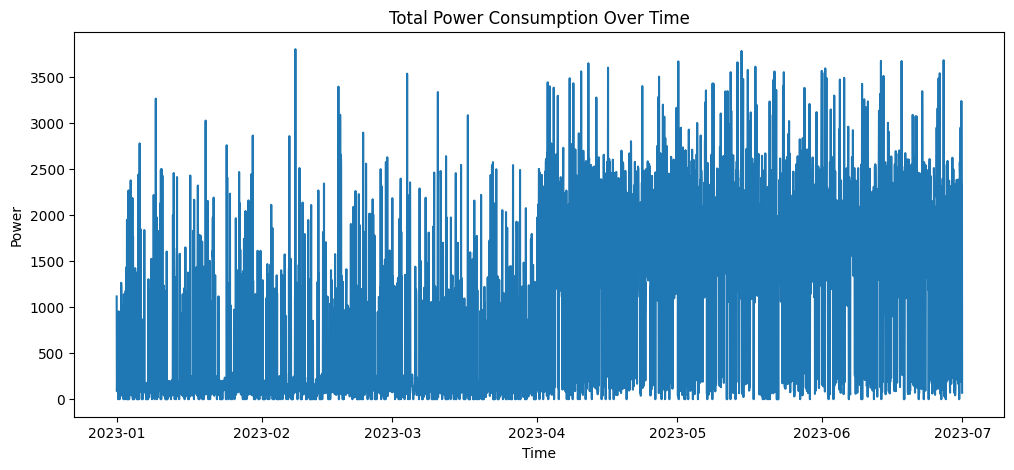

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['total_power'])
plt.title("Total Power Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Power")
plt.show()

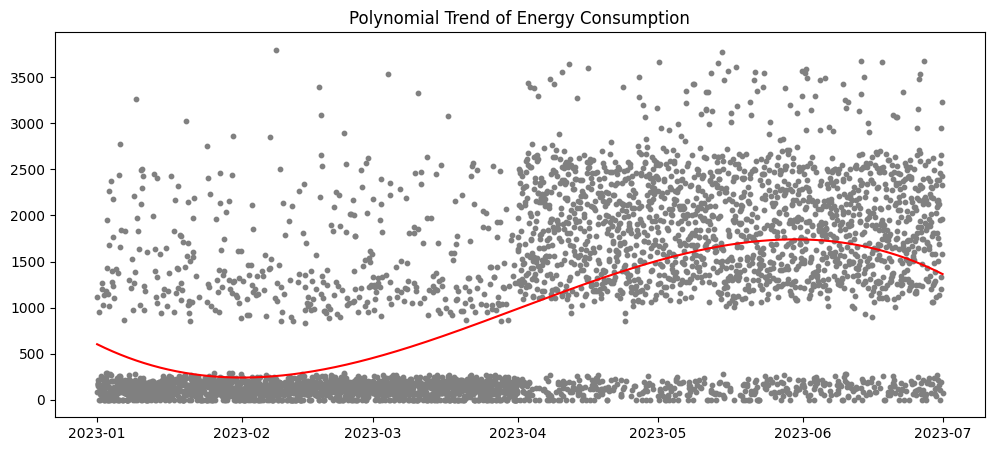

In [37]:
df['time_index'] = np.arange(len(df))
X = df[['time_index']]
y = df['total_power']
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly,y)
y_pred = model.predict(X_poly)
plt.figure(figsize=(12,5))
plt.scatter(df.index,y,s=10,color='gray')
plt.plot(df.index,y_pred,color='red')
plt.title("Polynomial Trend of Energy Consumption")
plt.show()

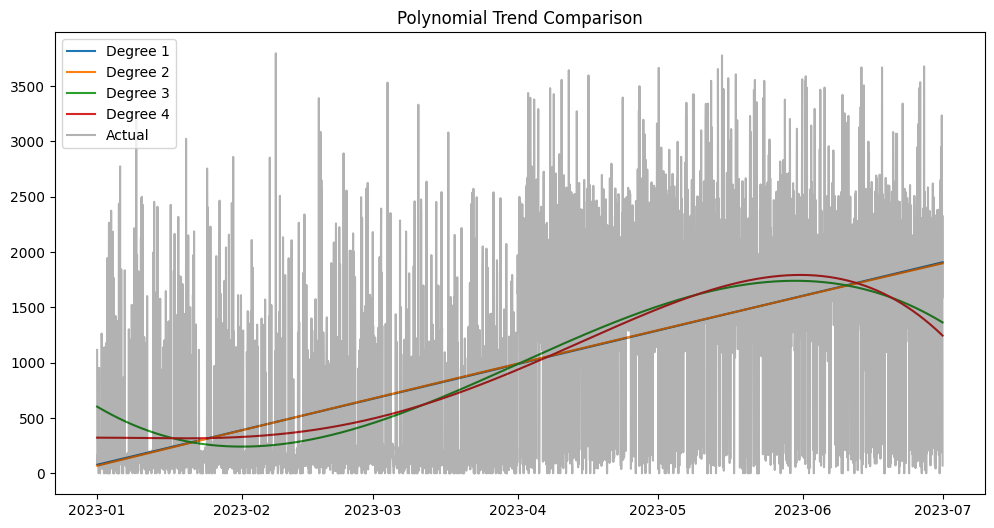

In [36]:
degrees = [1,2,3,4]
plt.figure(figsize=(12,6))
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly,y)
    y_pred = model.predict(X_poly)
    plt.plot(df.index,y_pred,label=f"Degree {d}")
plt.plot(df.index,y,color='black',alpha=0.3,label="Actual")
plt.legend()
plt.title("Polynomial Trend Comparison")
plt.show()

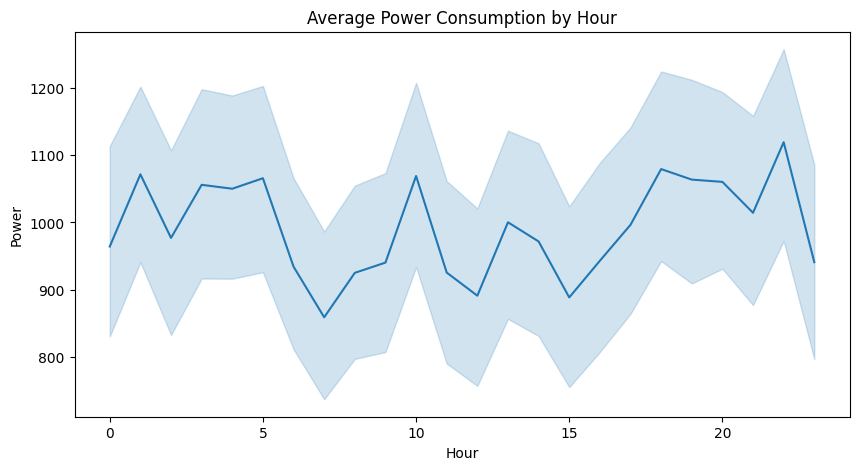

In [35]:
df['hour_sin'] = np.sin(2*np.pi*df.index.hour/24)
df['hour_cos'] = np.cos(2*np.pi*df.index.hour/24)
df['month_sin'] = np.sin(2*np.pi*df.index.month/12)
df['month_cos'] = np.cos(2*np.pi*df.index.month/12)
plt.figure(figsize=(10,5))
sns.lineplot(x=df.index.hour,y=df['total_power'])
plt.title("Average Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Power")
plt.show()

In [34]:
def calculate_entropy(series,bins=30):
    counts,_ = np.histogram(series,bins=bins,density=True)
    probs = counts/np.sum(counts)
    probs = probs[probs>0]
    return -np.sum(probs*np.log2(probs))
entropy_val = calculate_entropy(df['total_power'])
print("Entropy:",entropy_val)

Entropy: 3.6178320234053163


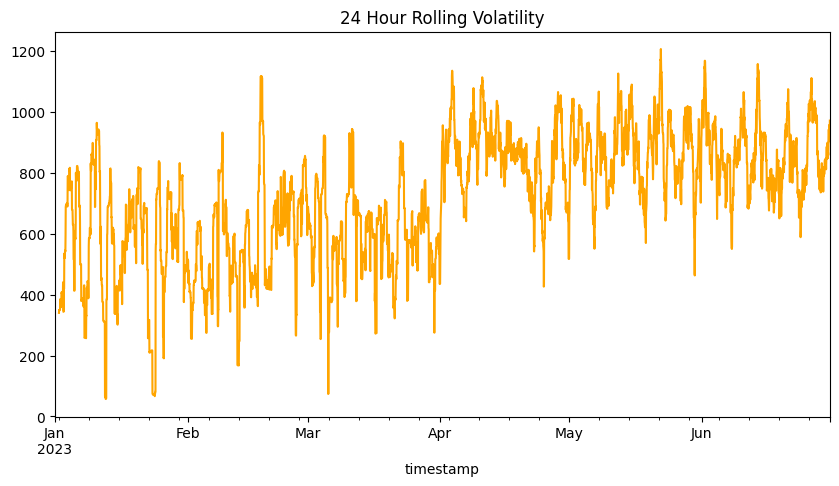

In [33]:
df['volatility'] = df['total_power'].rolling(window=24).std()
plt.figure(figsize=(10,5))
df['volatility'].plot(color='orange')
plt.title("24 Hour Rolling Volatility")
plt.show()

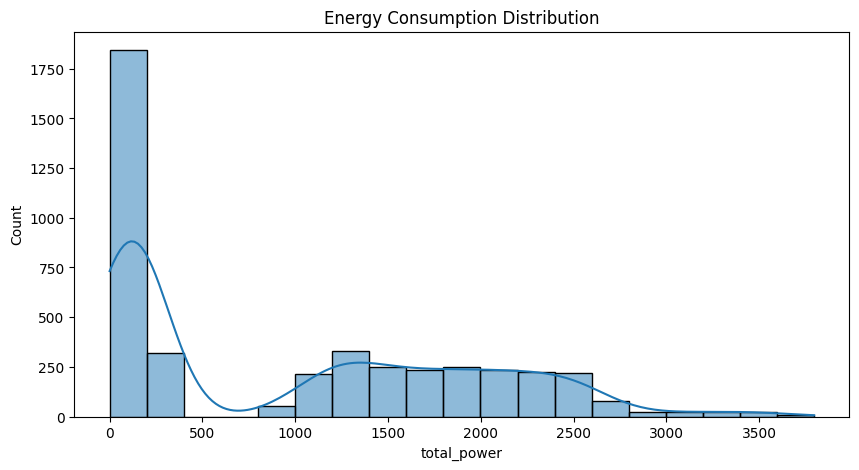

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(df['total_power'],kde=True)
plt.title("Energy Consumption Distribution")
plt.show()

C:\Users\Disha S\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_continuous_distns.py:6940: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
C:\Users\Disha S\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Disha S\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2085: RuntimeWarning: overflow encountered in divide
  place(output, cond, self._pdf(*goodargs) / scale)


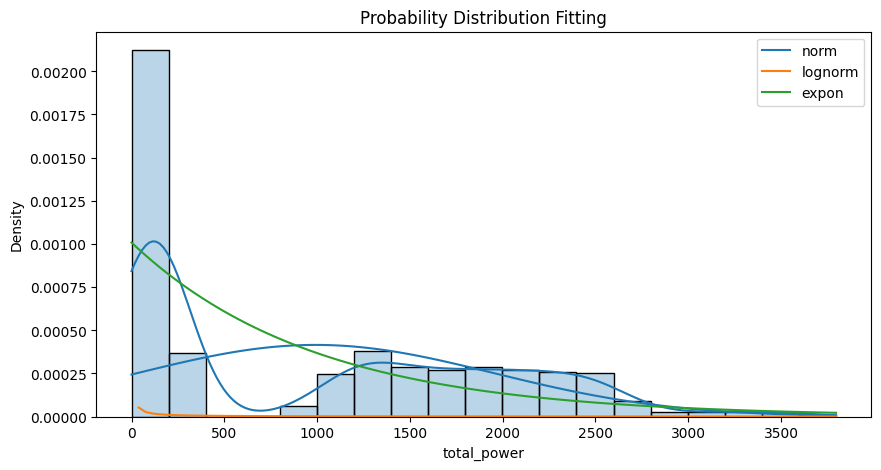

In [32]:
data = df['total_power']
plt.figure(figsize=(10,5))
sns.histplot(data,kde=True,stat="density",alpha=0.3)
x = np.linspace(min(data),max(data),100)
for dist in [stats.norm,stats.lognorm,stats.expon]:
    params = dist.fit(data)
    pdf = dist.pdf(x,*params)
    plt.plot(x,pdf,label=dist.name)
plt.legend()
plt.title("Probability Distribution Fitting")
plt.show()

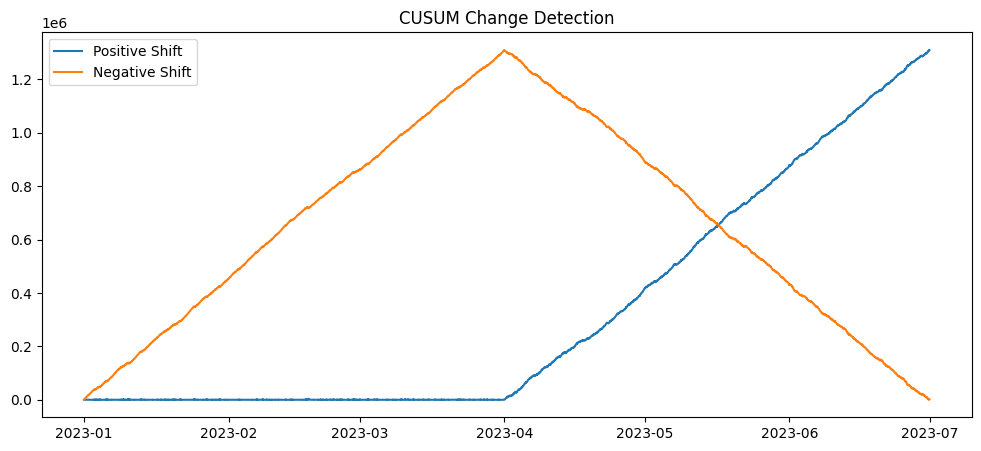

In [31]:
def detect_cusum(x,threshold=5,drift=0.5):
    S_pos = np.zeros(len(x))
    S_neg = np.zeros(len(x))
    mu = np.mean(x)
    for i in range(1,len(x)):
        S_pos[i] = max(0,S_pos[i-1] + (x[i]-mu)-drift)
        S_neg[i] = max(0,S_neg[i-1] - (x[i]-mu)-drift)
    return S_pos,S_neg
S_pos,S_neg = detect_cusum(df['total_power'].values)
plt.figure(figsize=(12,5))
plt.plot(df.index,S_pos,label="Positive Shift")
plt.plot(df.index,S_neg,label="Negative Shift")
plt.legend()
plt.title("CUSUM Change Detection")
plt.show()

C:\Users\Disha S\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


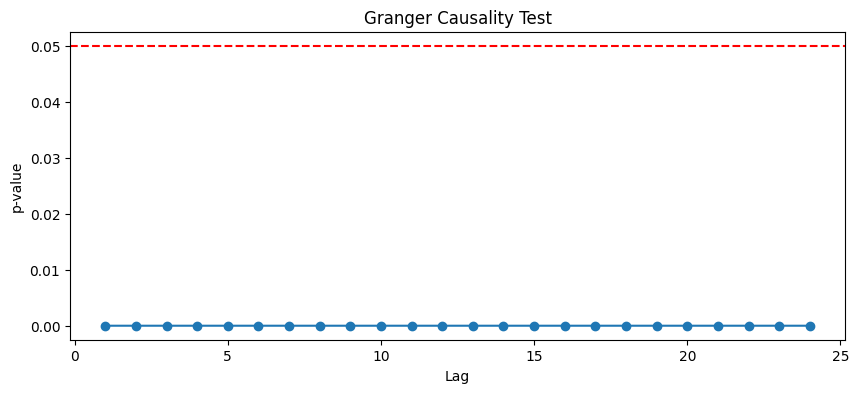

In [30]:
data_gc = df[['total_power','ac']].dropna()
gc_res = grangercausalitytests(data_gc,maxlag=24,verbose=False)
p_values = [gc_res[i+1][0]['ssr_chi2test'][1] for i in range(24)]
plt.figure(figsize=(10,4))
plt.plot(range(1,25),p_values,marker='o')
plt.axhline(0.05,color='red',linestyle='--')
plt.title("Granger Causality Test")
plt.xlabel("Lag")
plt.ylabel("p-value")
plt.show()

C:\Users\Disha S\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


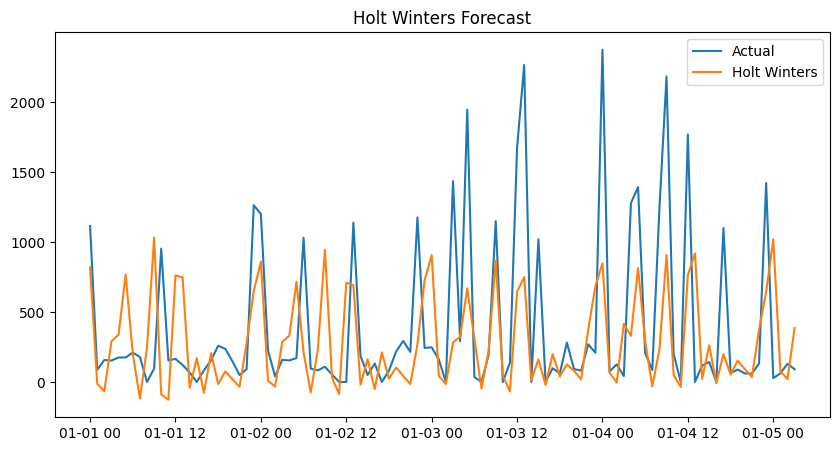

In [29]:
model = ExponentialSmoothing(
    df['total_power'][:500],
    seasonal_periods=24,
    trend='add',
    seasonal='add'
).fit()
forecast = model.fittedvalues
plt.figure(figsize=(10,5))
plt.plot(df['total_power'][:100],label="Actual")
plt.plot(forecast[:100],label="Holt Winters")
plt.legend()
plt.title("Holt Winters Forecast")
plt.show()

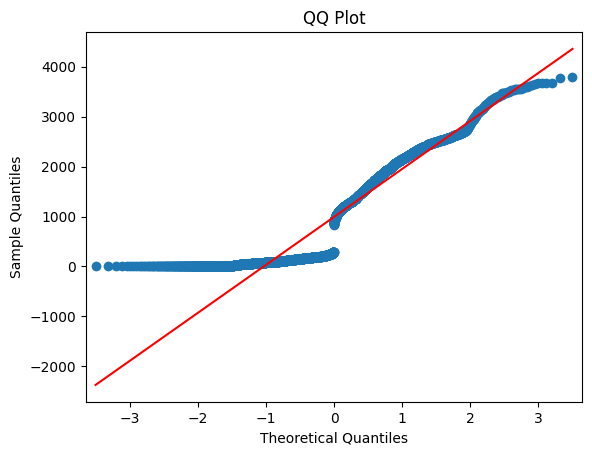

In [24]:
sm.qqplot(df['total_power'],line='s')
plt.title("QQ Plot")
plt.show()

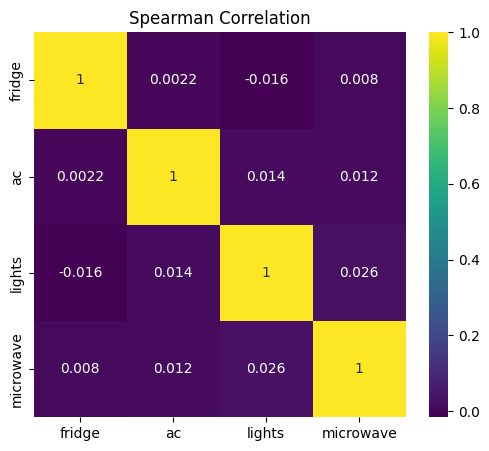

In [28]:
device_cols = ['fridge','ac','lights','microwave']
spearman_corr = df[device_cols].corr(method='spearman')
plt.figure(figsize=(6,5))
sns.heatmap(spearman_corr,annot=True,cmap='viridis')
plt.title("Spearman Correlation")
plt.show()

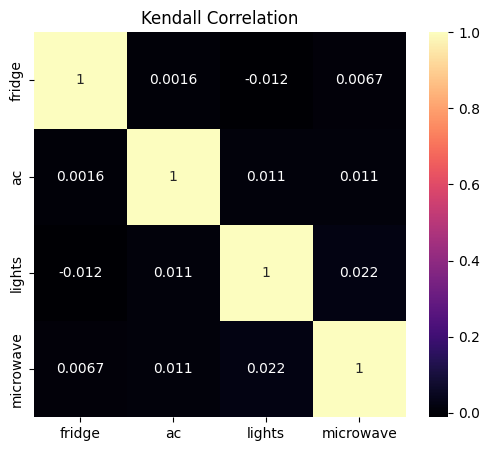

In [26]:
kendall_corr = df[device_cols].corr(method='kendall')
plt.figure(figsize=(6,5))
sns.heatmap(kendall_corr,annot=True,cmap='magma')
plt.title("Kendall Correlation")
plt.show()